In [1]:
import pickle
from typing import Optional
from functools import partial

import jax
import optax
import optuna
import equinox as eqx
import jax.numpy as jnp
import snnax.snn as snn
import jax.random as jrandom
import optuna.storages.journal
from chex import Array, PRNGKey
from tqdm import trange
import seaborn as sns
from eleanor.models import Heracles
from eleanor.datasets import shuffle, loadBraille
from eleanor.weight_quantization import QuantizedLinear

In [2]:
import os
from pathlib import Path
import pandas as pd

model_name = ["LIF", "RLIF", "FeLIF"]
quantizations = ["FP", 8, 4, 3]

df = pd.DataFrame()
for model in model_name:
    for quantization in quantizations:
        logdir = f"gradients/{quantization}bit_{model}"
        if os.path.exists(logdir):
            for filename in os.listdir(logdir):
                f = os.path.join(logdir, filename)
                # checking if it is a file
                if os.path.isfile(f):
                    df = pd.concat(
                        [df, pd.read_pickle(f)],
                        ignore_index=True,
                    )

ModuleNotFoundError: No module named 'numpy._core.numeric'

In [18]:
df

,Accuracy,Loss,Epoch,Seed,Quantization,Model
0,0.410156,2.954906,0,0,3,LIF
1,0.532227,1.825734,1,0,3,LIF
2,0.569336,1.584228,2,0,3,LIF
3,0.553711,1.508560,3,0,3,LIF
4,0.569336,1.441374,4,0,3,LIF
...,...,...,...,...,...,...
325,0.678711,1.100507,35,0,3,FeLIF
326,0.695312,1.116053,36,0,3,FeLIF
327,0.688477,1.106321,37,0,3,FeLIF
328,0.676758,1.076689,38,0,3,FeLIF


In [19]:
quantizations

['FP', 8, 4, 3]

FP LIF: nan±nan - RLIF: nan±nan - FeLIF: nan±nan
8 LIF: nan±nan - RLIF: nan±nan - FeLIF: nan±nan
4 LIF: nan±nan - RLIF: nan±nan - FeLIF: nan±nan
3 LIF: 0.6226±0.0119 - RLIF: 0.5747±0.0021 - FeLIF: 0.6187±0.0104


/tmp/ipykernel_1923067/1096136481.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


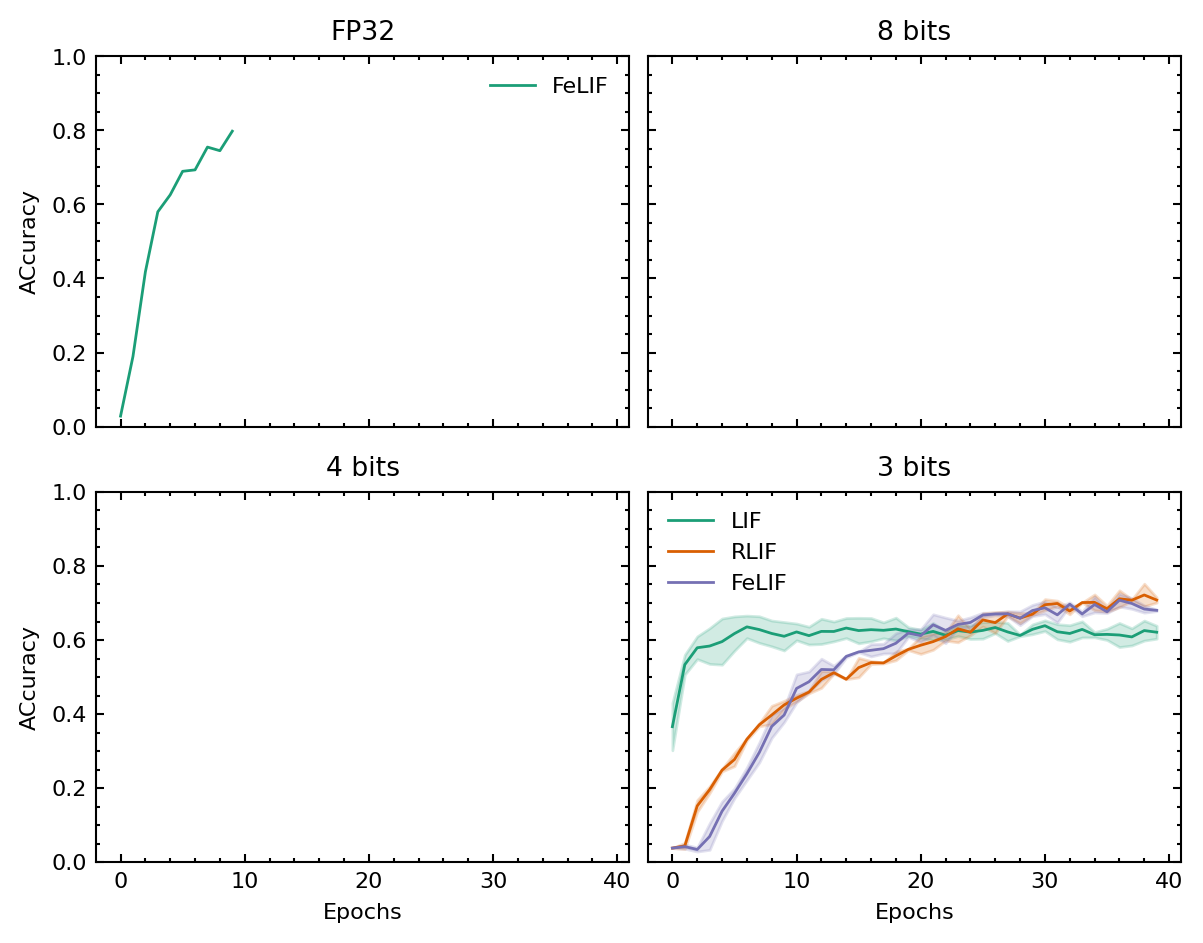

In [20]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

with mpl.style.context("boilerplot.ieeetran"):
    fig, axs = plt.subplots(
        2,
        2,
        figsize=[5.9, 4.6],
        dpi=200,
        constrained_layout=True,
        sharex=True,
        sharey=True,
    )
    cmap = plt.get_cmap("Dark2")  # Use tab20 colormap for multiple line plots.
    sns.set_palette("Dark2")
    # info = _get_edf_info(studies, None, "Accuracy")
    # edf_lines = info.lines

    # for i, (study_name, y_values) in enumerate(edf_lines):
    for it, quantization in enumerate(quantizations):
        i = it % 4
        try:
            dftmp = df[df["Quantization"] == str(quantization)]
            dftmp = dftmp[dftmp["Epoch"] == 19]
            dfLIF = dftmp[dftmp["Model"] == "LIF"]["Accuracy"]
            dfRLIF = dftmp[dftmp["Model"] == "RLIF"]["Accuracy"]
            dfFeLIF = dftmp[dftmp["Model"] == "FeLIF"]["Accuracy"]
            print(
                f"{quantization} LIF: {dfLIF.mean():.4f}±{dfLIF.std():.4f} - RLIF: {dfRLIF.mean():.4f}±{dfRLIF.std():.4f} - FeLIF: {dfFeLIF.mean():.4f}±{dfFeLIF.std():.4f}"
            )
            sns.lineplot(
                df[df["Quantization"] == str(quantization)],
                x="Epoch",
                y="Accuracy",
                hue="Model",
                errorbar="sd",
                ax=axs[i // 2, i % 2],
            )
            # sns.lineplot(df[df['Quantization'] == str(quantization)], x="Epoch", y="Accuracy", ax=axs[i//2,i%2])
            axs[i // 2, i % 2].set_title(
                "FP32" if quantization == "FP" else f"{quantization} bits"
            )
            axs[i // 2, i % 2].set_xlabel("Epochs")
            axs[i // 2, i % 2].set_ylabel("ACcuracy")
            axs[i // 2, i % 2].set_ylim(0, 1)
        except:
            pass
        # ax.plot(info.x_values, y_values, color=cmap(i), alpha=0.7, label=study_name)

    # if len(edf_lines) >= 2:
    #     axs.legend()
    for ax in np.ravel(axs):
        ax.legend()
    plt.show()
    # plt.savefig("quantization_results.pdf")

In [ ]:
studies = []
model_name = ["LIF", "RLIF", "FeLIF"]
quantizations = ["FP", 8, 4, 3]
for model in model_name:
    for quantization in quantizations:
        storage = optuna.storages.RDBStorage("sqlite:///bruno.db")
        study = optuna.load_study(
            storage=storage, study_name=f"{quantization}bit {model}"
        )
        studies.append(study)

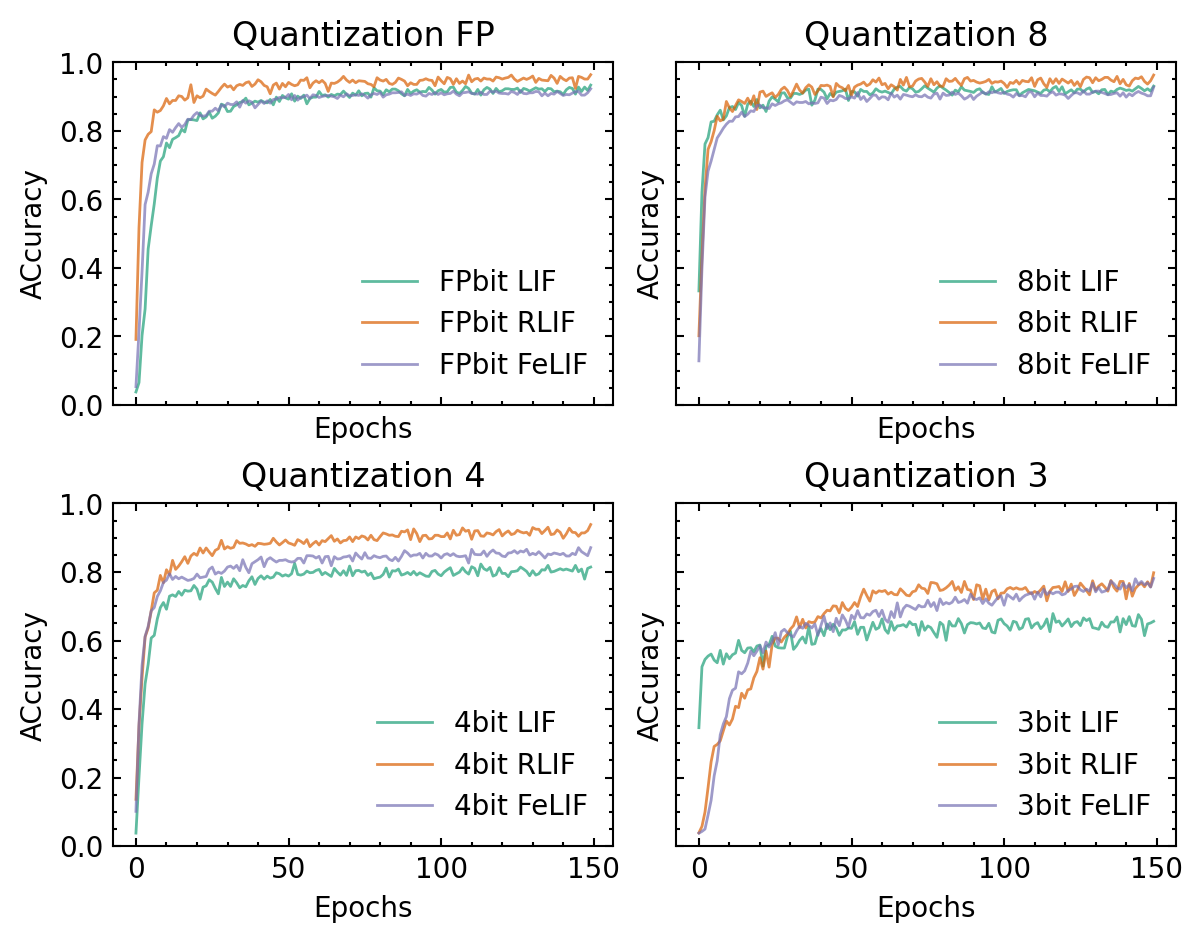

In [16]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

with mpl.style.context("boilerplot.ieeetran"):
    fig, axs = plt.subplots(
        2,
        2,
        figsize=[5.9, 4.6],
        dpi=200,
        constrained_layout=True,
        sharex=True,
        sharey=True,
    )
    cmap = plt.get_cmap("Dark2")  # Use tab20 colormap for multiple line plots.

    # info = _get_edf_info(studies, None, "Accuracy")
    # edf_lines = info.lines

    # for i, (study_name, y_values) in enumerate(edf_lines):
    for it, study in enumerate(studies):
        i = it % 4
        try:
            axs[i // 2, i % 2].plot(
                study.best_trial.intermediate_values.values(),
                color=cmap(it // 4),
                alpha=0.7,
                label=study.study_name,
            )
            axs[i // 2, i % 2].set_title(f"Quantization {quantizations[i]}")
            axs[i // 2, i % 2].set_xlabel("Epochs")
            axs[i // 2, i % 2].set_ylabel("ACcuracy")
            axs[i // 2, i % 2].set_ylim(0, 1)
        except:
            pass
        # ax.plot(info.x_values, y_values, color=cmap(i), alpha=0.7, label=study_name)

    # if len(edf_lines) >= 2:
    #     axs.legend()
    for ax in np.ravel(axs):
        ax.legend()
    plt.show()
    # plt.savefig("EDF.png")

In [18]:
from plotly.io import show

studies = []
model_name = ["LIF", "RLIF", "FeLIF"]
quantizations = [3]
for model in model_name:
    for quantization in quantizations:
        storage = optuna.storages.RDBStorage("sqlite:///bruno.db")
        study = optuna.load_study(
            storage=storage, study_name=f"{quantization}bit {model}"
        )
        studies.append(study)

fig = optuna.visualization.plot_edf(studies)
show(fig)